
GMM SANDBOX: COMPREHENSIVE TUTORIAL


PART 1: SCORE, HESSIAN & FISHER INFORMATION
--------------------------------------------------------------------------------
DERIVATIVE ANALYSIS AT x = 2.300
Parameters: mu = 1.500, sigma = 1.200

1. LOG-LIKELIHOOD
   L(mu, sigma | x) = -1.323482

2. SCORE (First Derivatives)
   dL/dmu  = 0.555556
   dL/dsigma  = -0.462963

3. HESSIAN (Second Derivatives)
   d2L/dmu2 = -0.694444
   d2L/dsigma2 = 0.385802
   d2L/dmu*dsigma = -0.925926

4. FISHER INFORMATION
   I(mu, mu) = 0.694444
   I(sigma, sigma) = 1.388889
   Var(mu_hat) >= 1.440000


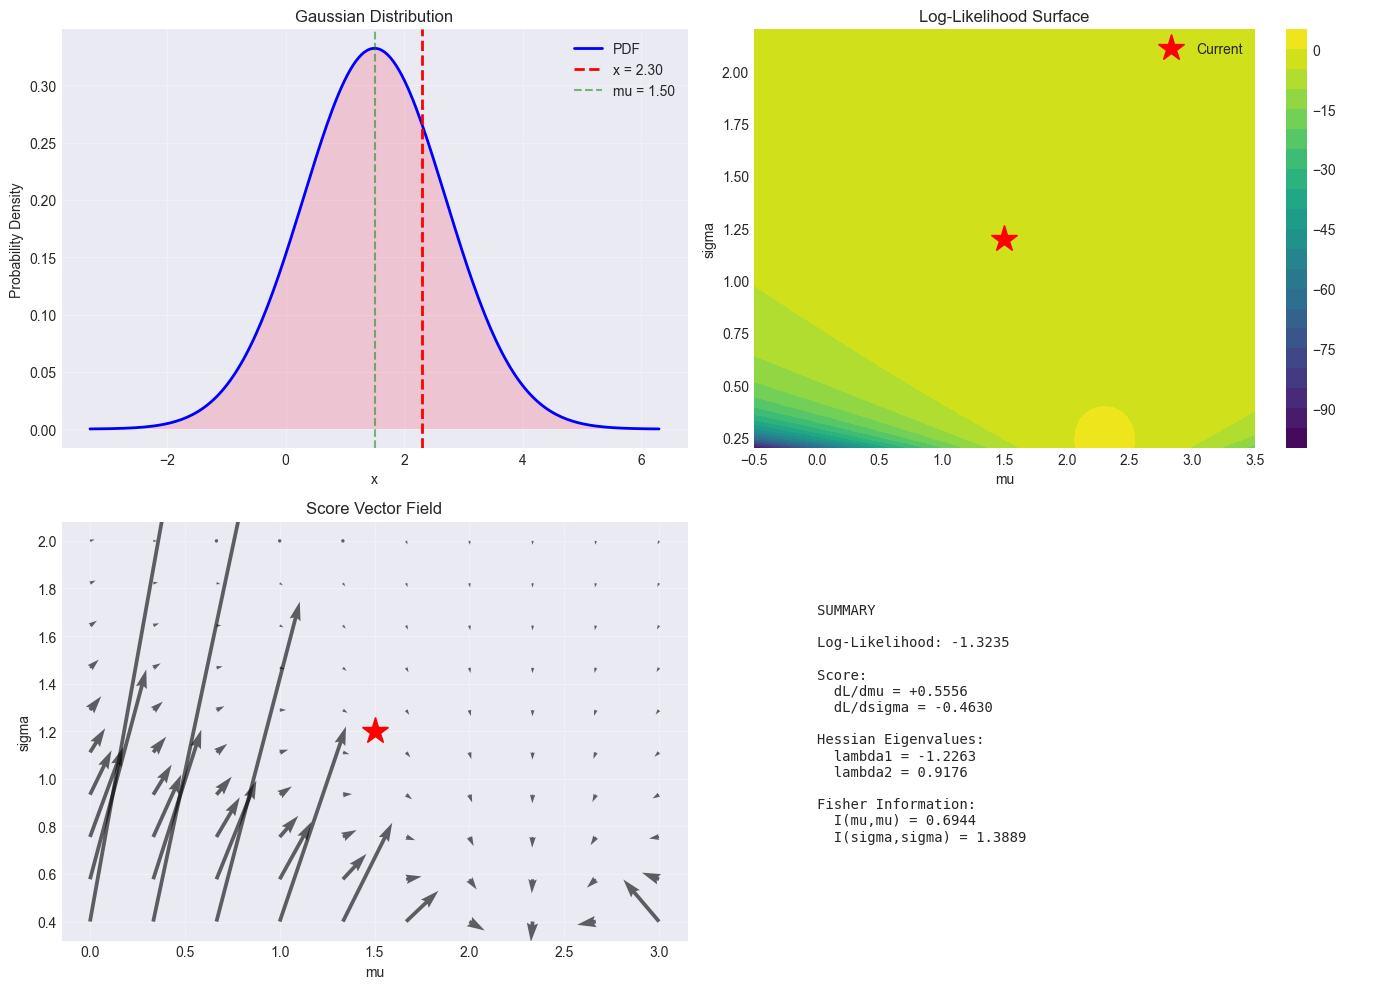


Visualization saved as 'gmm_derivatives.png'


PART 2: EM ALGORITHM (2 COMPONENTS)
--------------------------------------------------------------------------------

EM ALGORITHM FOR 2-COMPONENT GMM
Iter   LogLik       W1         M1         S1         W2         M2         S2         
----------------------------------------------------------------------------------------------------
1      -432.4604    0.4469     0.8506     2.0208     0.5531     -0.1336    2.0667     
2      -432.4448    0.4469     0.8650     2.0075     0.5531     -0.1451    2.0716     
3      -432.4302    0.4466     0.8820     1.9990     0.5534     -0.1583    2.0716     
4      -432.4133    0.4463     0.9009     1.9916     0.5537     -0.1730    2.0697     
5      -432.3927    0.4460     0.9217     1.9840     0.5540     -0.1891    2.0668     
6      -432.3676    0.4456     0.9446     1.9756     0.5544     -0.2067    2.0633     
7      -432.3363    0.4452     0.9699     1.9661     0.5548     -0.2261    2.0592     
8   

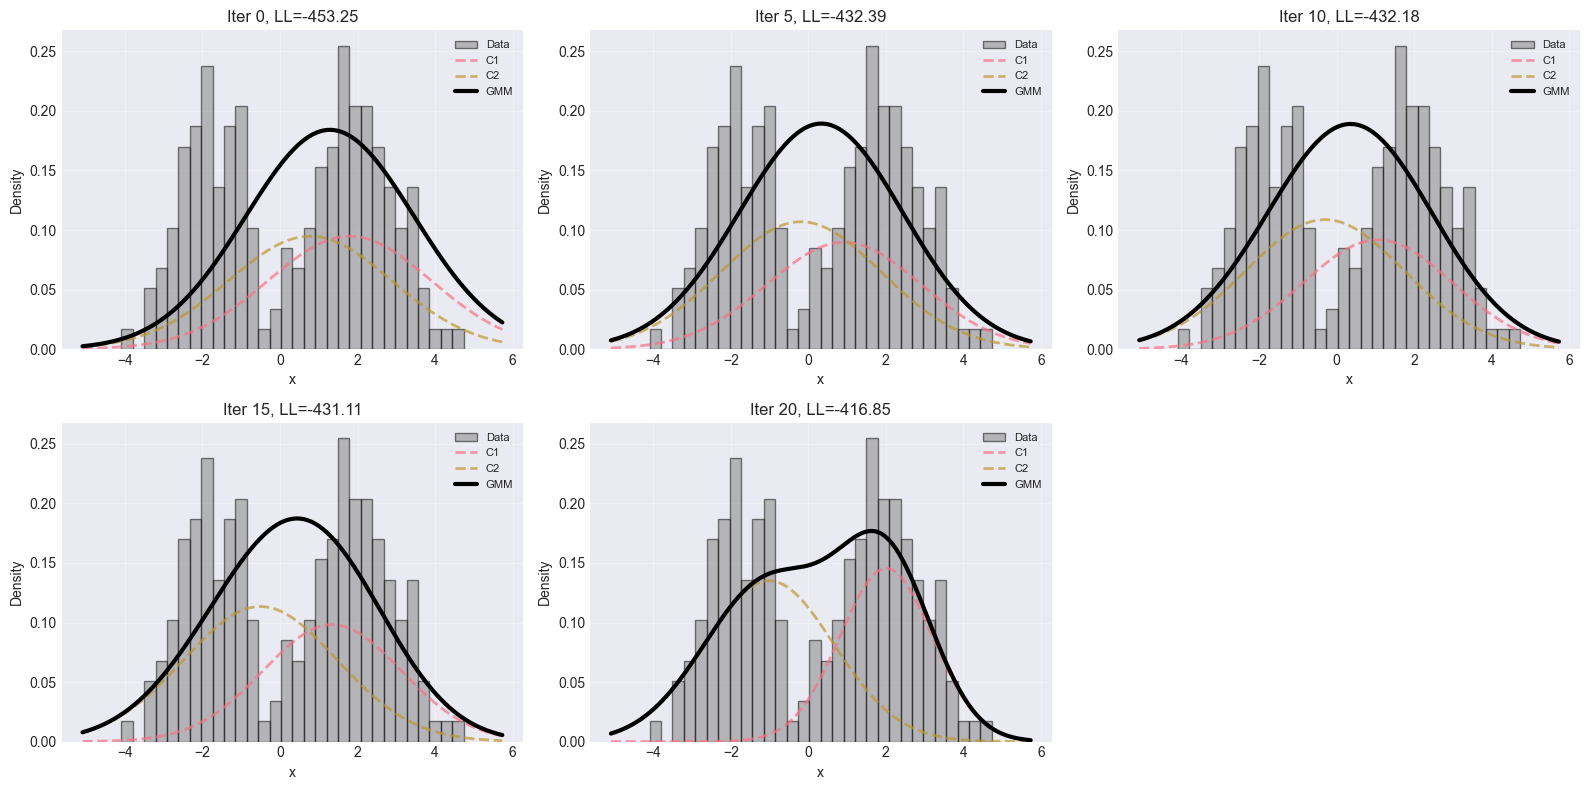


DETAILED STEPS:

ITERATION 0 DETAILS

Parameters:
  Component 1: w=0.5000, mu=1.7975, sigma=2.1040
  Component 2: w=0.5000, mu=0.7794, sigma=2.1040

Log-Likelihood: -453.245442

ITERATION 5 DETAILS

Parameters:
  Component 1: w=0.4460, mu=0.9217, sigma=1.9840
  Component 2: w=0.5540, mu=-0.1891, sigma=2.0668

Log-Likelihood: -432.392748

Responsibilities (first 10 points):
x          gamma1       gamma2       
-2.8895    0.244760     0.755240     
-1.7449    0.316255     0.683745     
-1.7768    0.314187     0.685813     
3.0105     0.609435     0.390565     
-2.4647    0.270539     0.729461     
-2.4201    0.273302     0.726698     
-4.0900    0.178560     0.821440     
-1.2397    0.349367     0.650633     
1.5720     0.530369     0.469631     
-2.5939    0.262588     0.737412     

ITERATION -1 DETAILS

Parameters:
  Component 1: w=0.4359, mu=2.0077, sigma=1.1960
  Component 2: w=0.5641, mu=-1.0084, sigma=1.6665

Log-Likelihood: -416.851921

Responsibilities (first 10 points):
x    

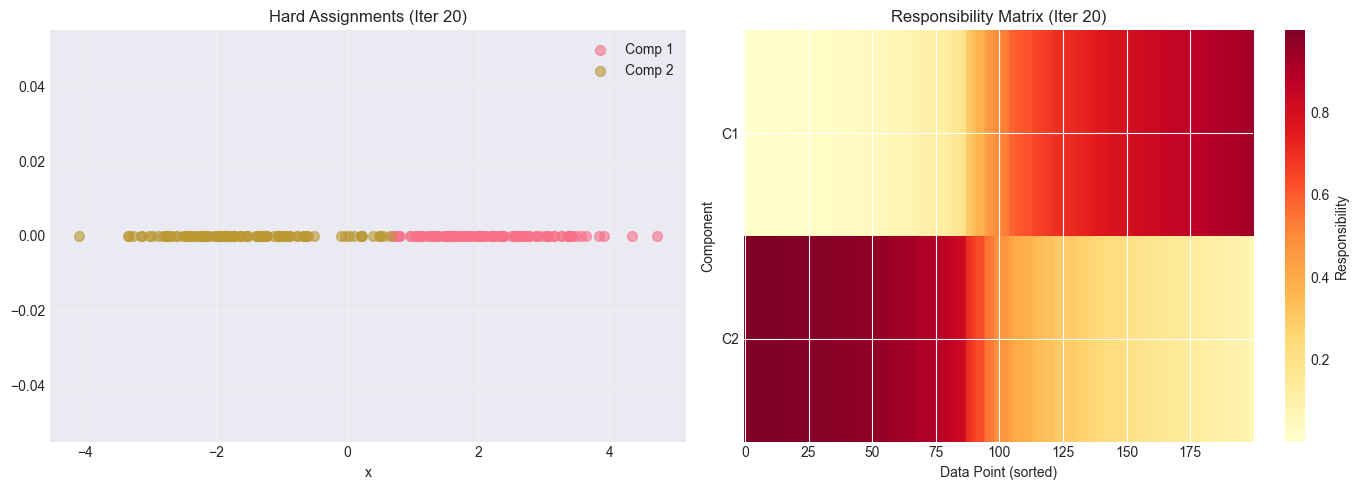



PART 3: EM ALGORITHM (3 COMPONENTS)
--------------------------------------------------------------------------------

EM ALGORITHM FOR 3-COMPONENT GMM
Iter   LogLik       W1         M1         S1         W2         M2         S2         W3         M3         S3         
----------------------------------------------------------------------------------------------------
1      -673.6937    0.2291     1.6591     1.7337     0.5242     -1.3740    1.8335     0.2467     1.5294     1.7648     
2      -673.0768    0.2301     1.7100     1.6677     0.5229     -1.4273    1.8027     0.2470     1.5791     1.7112     
3      -672.6619    0.2306     1.7562     1.6249     0.5225     -1.4687    1.7673     0.2468     1.6185     1.6725     
4      -672.4099    0.2310     1.7939     1.5961     0.5225     -1.4992    1.7361     0.2466     1.6471     1.6446     
5      -672.2744    0.2312     1.8234     1.5763     0.5226     -1.5204    1.7121     0.2462     1.6659     1.6251     
6      -672.2082    0.2312

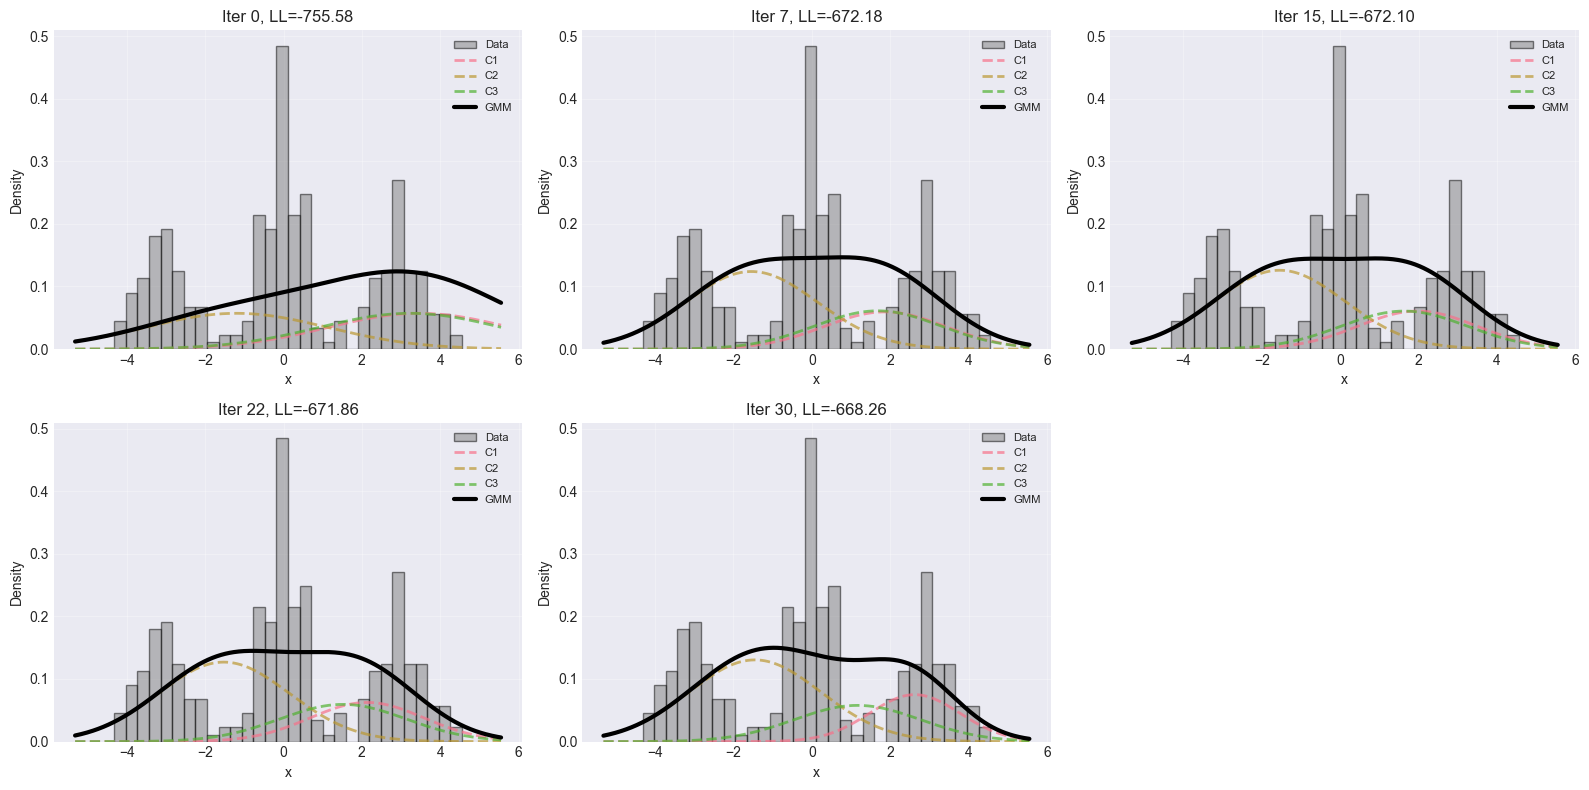

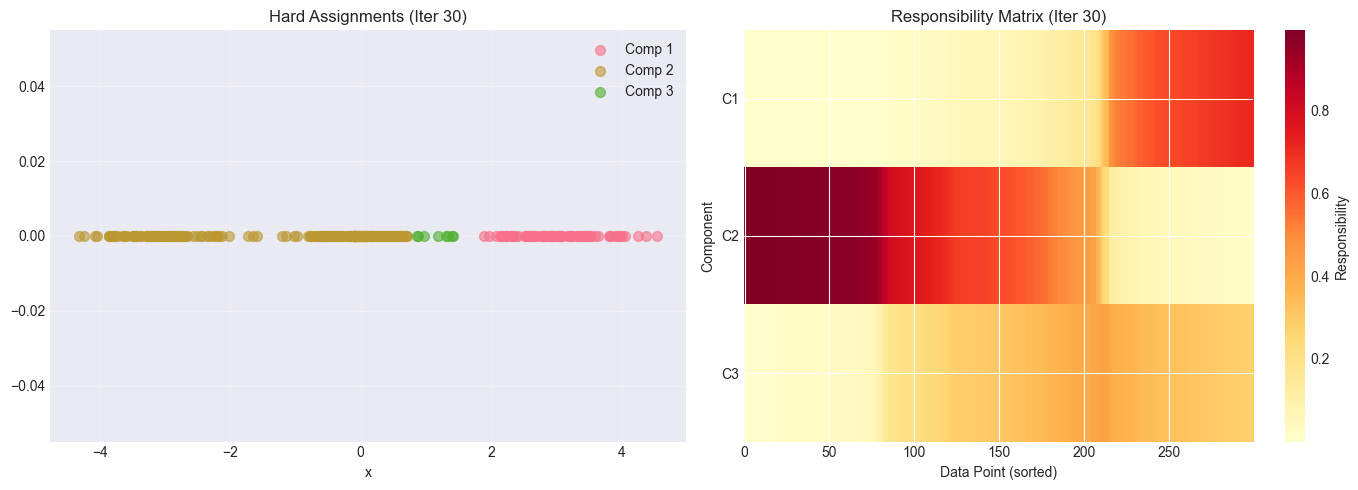



TUTORIAL COMPLETE!


In [1]:
"""
GMM Sandbox: Interactive Exploration of Score, Hessian, Fisher Information and EM Algorithm

This script provides comprehensive tools to understand Gaussian Mixture Models through:
1. Derivative analysis (Score, Hessian, Fisher Information)
2. Complete EM algorithm with step-by-step visualization

Usage: python gmm_sandbox.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class GMMDerivativesExplorer:
    """Explore Score, Hessian, and Fisher Information for a single Gaussian"""

    def __init__(self, mu=0.0, sigma=1.0):
        self.mu = mu
        self.sigma = sigma

    def log_likelihood(self, x):
        """Compute log-likelihood for a single observation"""
        return norm.logpdf(x, loc=self.mu, scale=self.sigma)

    def score(self, x):
        """Compute the score (gradient) of log-likelihood"""
        score_mu = (x - self.mu) / (self.sigma ** 2)
        score_sigma = ((x - self.mu) ** 2) / (self.sigma ** 3) - 1 / self.sigma
        return score_mu, score_sigma

    def hessian(self, x):
        """Compute the Hessian matrix"""
        hess_mu_mu = -1 / (self.sigma ** 2)
        hess_sigma_sigma = -((x - self.mu) ** 2) / (self.sigma ** 4) + 1 / (self.sigma ** 2)
        hess_mu_sigma = -2 * (x - self.mu) / (self.sigma ** 3)

        H = np.array([[hess_mu_mu, hess_mu_sigma],
                      [hess_mu_sigma, hess_sigma_sigma]])
        return H

    def fisher_information(self):
        """Compute Fisher Information Matrix"""
        I_mu_mu = 1 / (self.sigma ** 2)
        I_sigma_sigma = 2 / (self.sigma ** 2)
        I_mu_sigma = 0

        I = np.array([[I_mu_mu, I_mu_sigma],
                      [I_mu_sigma, I_sigma_sigma]])
        return I

    def visualize_derivatives(self, x):
        """Comprehensive visualization of derivatives at point x"""
        ll = self.log_likelihood(x)
        score_mu, score_sigma = self.score(x)
        H = self.hessian(x)
        I = self.fisher_information()

        print("=" * 80)
        print(f"DERIVATIVE ANALYSIS AT x = {x:.3f}")
        print(f"Parameters: mu = {self.mu:.3f}, sigma = {self.sigma:.3f}")
        print("=" * 80)

        print(f"\n1. LOG-LIKELIHOOD")
        print(f"   L(mu, sigma | x) = {ll:.6f}")

        print(f"\n2. SCORE (First Derivatives)")
        print(f"   dL/dmu  = {score_mu:.6f}")
        print(f"   dL/dsigma  = {score_sigma:.6f}")

        print(f"\n3. HESSIAN (Second Derivatives)")
        print(f"   d2L/dmu2 = {H[0,0]:.6f}")
        print(f"   d2L/dsigma2 = {H[1,1]:.6f}")
        print(f"   d2L/dmu*dsigma = {H[0,1]:.6f}")

        print(f"\n4. FISHER INFORMATION")
        print(f"   I(mu, mu) = {I[0,0]:.6f}")
        print(f"   I(sigma, sigma) = {I[1,1]:.6f}")
        print(f"   Var(mu_hat) >= {1/I[0,0]:.6f}")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 1: PDF
        x_range = np.linspace(self.mu - 4*self.sigma, self.mu + 4*self.sigma, 200)
        pdf_values = norm.pdf(x_range, loc=self.mu, scale=self.sigma)

        axes[0, 0].plot(x_range, pdf_values, 'b-', linewidth=2, label='PDF')
        axes[0, 0].axvline(x, color='r', linestyle='--', linewidth=2, label=f'x = {x:.2f}')
        axes[0, 0].axvline(self.mu, color='g', linestyle='--', alpha=0.5, label=f'mu = {self.mu:.2f}')
        axes[0, 0].fill_between(x_range, 0, pdf_values, alpha=0.3)
        axes[0, 0].set_xlabel('x')
        axes[0, 0].set_ylabel('Probability Density')
        axes[0, 0].set_title('Gaussian Distribution')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Plot 2: Log-likelihood surface
        mu_range = np.linspace(self.mu - 2, self.mu + 2, 50)
        sigma_range = np.linspace(max(0.1, self.sigma - 1), self.sigma + 1, 50)
        MU, SIGMA = np.meshgrid(mu_range, sigma_range)
        LL = np.zeros_like(MU)

        for i in range(len(sigma_range)):
            for j in range(len(mu_range)):
                LL[i, j] = norm.logpdf(x, loc=MU[i, j], scale=SIGMA[i, j])

        contour = axes[0, 1].contourf(MU, SIGMA, LL, levels=20, cmap='viridis')
        axes[0, 1].plot(self.mu, self.sigma, 'r*', markersize=20, label='Current')
        axes[0, 1].set_xlabel('mu')
        axes[0, 1].set_ylabel('sigma')
        axes[0, 1].set_title('Log-Likelihood Surface')
        axes[0, 1].legend()
        plt.colorbar(contour, ax=axes[0, 1])

        # Plot 3: Score vector field
        mu_range_small = np.linspace(self.mu - 1.5, self.mu + 1.5, 10)
        sigma_range_small = np.linspace(max(0.2, self.sigma - 0.8), self.sigma + 0.8, 10)
        MU_small, SIGMA_small = np.meshgrid(mu_range_small, sigma_range_small)

        U = np.zeros_like(MU_small)
        V = np.zeros_like(SIGMA_small)

        for i in range(len(sigma_range_small)):
            for j in range(len(mu_range_small)):
                explorer = GMMDerivativesExplorer(MU_small[i, j], SIGMA_small[i, j])
                s_mu, s_sigma = explorer.score(x)
                U[i, j] = s_mu
                V[i, j] = s_sigma

        axes[1, 0].quiver(MU_small, SIGMA_small, U, V, alpha=0.6)
        axes[1, 0].plot(self.mu, self.sigma, 'r*', markersize=20)
        axes[1, 0].set_xlabel('mu')
        axes[1, 0].set_ylabel('sigma')
        axes[1, 0].set_title('Score Vector Field')
        axes[1, 0].grid(True, alpha=0.3)

        # Plot 4: Summary
        axes[1, 1].axis('off')
        info_text = f"""SUMMARY

Log-Likelihood: {ll:.4f}

Score:
  dL/dmu = {score_mu:+.4f}
  dL/dsigma = {score_sigma:+.4f}

Hessian Eigenvalues:
  lambda1 = {np.linalg.eigvals(H)[0]:.4f}
  lambda2 = {np.linalg.eigvals(H)[1]:.4f}

Fisher Information:
  I(mu,mu) = {I[0,0]:.4f}
  I(sigma,sigma) = {I[1,1]:.4f}
        """
        axes[1, 1].text(0.1, 0.5, info_text, fontsize=10, family='monospace',
                        verticalalignment='center')

        plt.tight_layout()
        plt.savefig('gmm_derivatives.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nVisualization saved as 'gmm_derivatives.png'")


class GMMEMAlgorithm:
    """Complete EM Algorithm for Gaussian Mixture Models"""

    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.weights_ = None
        self.means_ = None
        self.stds_ = None
        self.history_ = []

    def _initialize_parameters(self, X):
        """Initialize parameters"""
        n_samples = len(X)
        indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[indices].copy()
        self.stds_ = np.ones(self.n_components) * np.std(X)
        self.weights_ = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        """E-step: Compute responsibilities"""
        n_samples = len(X)
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * norm.pdf(
                X, loc=self.means_[k], scale=self.stds_[k]
            )

        responsibilities /= (responsibilities.sum(axis=1, keepdims=True) + 1e-10)
        return responsibilities

    def _m_step(self, X, responsibilities):
        """M-step: Update parameters"""
        n_samples = len(X)
        N_k = responsibilities.sum(axis=0)
        self.weights_ = N_k / n_samples
        self.means_ = (responsibilities.T @ X) / N_k

        for k in range(self.n_components):
            diff = X - self.means_[k]
            self.stds_[k] = np.sqrt((responsibilities[:, k] * diff ** 2).sum() / N_k[k])

    def _compute_log_likelihood(self, X):
        """Compute log-likelihood"""
        log_likelihood = 0
        for i in range(len(X)):
            prob = 0
            for k in range(self.n_components):
                prob += self.weights_[k] * norm.pdf(X[i], loc=self.means_[k], scale=self.stds_[k])
            log_likelihood += np.log(prob + 1e-10)
        return log_likelihood

    def fit(self, X, verbose=True):
        """Fit GMM using EM algorithm"""
        X = np.array(X).flatten()
        self._initialize_parameters(X)

        self.history_ = [{
            'iteration': 0,
            'means': self.means_.copy(),
            'stds': self.stds_.copy(),
            'weights': self.weights_.copy(),
            'log_likelihood': self._compute_log_likelihood(X),
            'responsibilities': None
        }]

        if verbose:
            print("\n" + "=" * 100)
            print(f"EM ALGORITHM FOR {self.n_components}-COMPONENT GMM")
            print("=" * 100)
            print(f"{'Iter':<6} {'LogLik':<12} ", end='')
            for k in range(self.n_components):
                print(f"{'W'+str(k+1):<10} {'M'+str(k+1):<10} {'S'+str(k+1):<10} ", end='')
            print()
            print("-" * 100)

        for iteration in range(1, self.max_iter + 1):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            log_likelihood = self._compute_log_likelihood(X)

            self.history_.append({
                'iteration': iteration,
                'means': self.means_.copy(),
                'stds': self.stds_.copy(),
                'weights': self.weights_.copy(),
                'log_likelihood': log_likelihood,
                'responsibilities': responsibilities.copy()
            })

            if verbose:
                print(f"{iteration:<6} {log_likelihood:<12.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{self.weights_[k]:<10.4f} {self.means_[k]:<10.4f} {self.stds_[k]:<10.4f} ", end='')
                print()

            if iteration > 1:
                ll_change = abs(log_likelihood - self.history_[-2]['log_likelihood'])
                if ll_change < self.tol:
                    if verbose:
                        print(f"\nConverged at iteration {iteration}")
                    break

        if verbose:
            print("=" * 100)
        return self

    def visualize_em_progress(self, X, iterations_to_show=None):
        """Visualize EM algorithm progress"""
        X = np.array(X).flatten()

        if iterations_to_show is None:
            total = len(self.history_) - 1
            iterations_to_show = [0, total // 4, total // 2, 3 * total // 4, total]
            iterations_to_show = sorted(list(set(iterations_to_show)))

        n_plots = len(iterations_to_show)
        fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(16, 8))
        axes = axes.flatten()

        x_range = np.linspace(X.min() - 1, X.max() + 1, 500)

        for idx, iter_num in enumerate(iterations_to_show):
            state = self.history_[iter_num]

            axes[idx].hist(X, bins=30, density=True, alpha=0.5, color='gray',
                          edgecolor='black', label='Data')

            gmm_pdf = np.zeros_like(x_range)
            for k in range(self.n_components):
                component_pdf = state['weights'][k] * norm.pdf(
                    x_range, loc=state['means'][k], scale=state['stds'][k]
                )
                axes[idx].plot(x_range, component_pdf, '--', linewidth=2,
                             label=f'C{k+1}', alpha=0.7)
                gmm_pdf += component_pdf

            axes[idx].plot(x_range, gmm_pdf, 'k-', linewidth=3, label='GMM')
            axes[idx].set_xlabel('x')
            axes[idx].set_ylabel('Density')
            axes[idx].set_title(f"Iter {iter_num}, LL={state['log_likelihood']:.2f}")
            axes[idx].legend(fontsize=8)
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(iterations_to_show), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig('gmm_em_progress.png', dpi=150, bbox_inches='tight')
        plt.show()

    def visualize_responsibilities(self, X, iteration=-1):
        """Visualize responsibilities"""
        X = np.array(X).flatten()
        state = self.history_[iteration]

        if state['responsibilities'] is None:
            print("No responsibilities for this iteration")
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        responsibilities = state['responsibilities']
        assignments = responsibilities.argmax(axis=1)

        for k in range(self.n_components):
            mask = assignments == k
            axes[0].scatter(X[mask], np.zeros(mask.sum()),
                          alpha=0.6, s=50, label=f'Comp {k+1}')

        axes[0].set_xlabel('x')
        axes[0].set_title(f'Hard Assignments (Iter {state["iteration"]})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        sorted_indices = np.argsort(X)
        im = axes[1].imshow(responsibilities[sorted_indices].T, aspect='auto',
                           cmap='YlOrRd', interpolation='nearest')

        axes[1].set_xlabel('Data Point (sorted)')
        axes[1].set_ylabel('Component')
        axes[1].set_title(f'Responsibility Matrix (Iter {state["iteration"]})')
        axes[1].set_yticks(range(self.n_components))
        axes[1].set_yticklabels([f'C{k+1}' for k in range(self.n_components)])

        plt.colorbar(im, ax=axes[1], label='Responsibility')
        plt.tight_layout()
        plt.savefig('gmm_responsibilities.png', dpi=150, bbox_inches='tight')
        plt.show()

    def print_detailed_step(self, X, iteration):
        """Print detailed iteration information"""
        X = np.array(X).flatten()
        state = self.history_[iteration]

        print("\n" + "=" * 80)
        print(f"ITERATION {iteration} DETAILS")
        print("=" * 80)

        print(f"\nParameters:")
        for k in range(self.n_components):
            print(f"  Component {k+1}: w={state['weights'][k]:.4f}, "
                  f"mu={state['means'][k]:.4f}, sigma={state['stds'][k]:.4f}")

        print(f"\nLog-Likelihood: {state['log_likelihood']:.6f}")

        if state['responsibilities'] is not None:
            print(f"\nResponsibilities (first 10 points):")
            print(f"{'x':<10} ", end='')
            for k in range(self.n_components):
                print(f"{'gamma'+str(k+1):<12} ", end='')
            print()

            for i in range(min(10, len(X))):
                print(f"{X[i]:<10.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{state['responsibilities'][i, k]:<12.6f} ", end='')
                print()


def generate_gmm_data(n_samples=300, n_components=2, random_state=42):
    """Generate synthetic GMM data"""
    np.random.seed(random_state)

    if n_components == 2:
        means = [-2, 2]
        stds = [0.8, 1.0]
        weights = [0.4, 0.6]
    else:
        means = [-3, 0, 3]
        stds = [0.6, 0.6, 0.6]
        weights = [0.3, 0.4, 0.3]

    samples = []
    for _ in range(n_samples):
        k = np.random.choice(n_components, p=weights)
        x = np.random.normal(means[k], stds[k])
        samples.append(x)

    return np.array(samples)


def main():
    """Main demonstration"""

    print("\n" + "=" * 80)
    print("GMM SANDBOX: COMPREHENSIVE TUTORIAL")
    print("=" * 80)

    # PART 1: Derivatives
    print("\n\nPART 1: SCORE, HESSIAN & FISHER INFORMATION")
    print("-" * 80)

    explorer = GMMDerivativesExplorer(mu=1.5, sigma=1.2)
    explorer.visualize_derivatives(x=2.3)

    # PART 2: EM Algorithm (2 components)
    print("\n\nPART 2: EM ALGORITHM (2 COMPONENTS)")
    print("-" * 80)

    X_2comp = generate_gmm_data(n_samples=200, n_components=2)

    gmm_2 = GMMEMAlgorithm(n_components=2, max_iter=20)
    gmm_2.fit(X_2comp, verbose=True)

    gmm_2.visualize_em_progress(X_2comp)

    print("\nDETAILED STEPS:")
    gmm_2.print_detailed_step(X_2comp, iteration=0)
    gmm_2.print_detailed_step(X_2comp, iteration=5)
    gmm_2.print_detailed_step(X_2comp, iteration=-1)

    gmm_2.visualize_responsibilities(X_2comp, iteration=-1)

    # PART 3: EM Algorithm (3 components)
    print("\n\nPART 3: EM ALGORITHM (3 COMPONENTS)")
    print("-" * 80)

    X_3comp = generate_gmm_data(n_samples=300, n_components=3, random_state=123)

    gmm_3 = GMMEMAlgorithm(n_components=3, max_iter=30)
    gmm_3.fit(X_3comp, verbose=True)

    gmm_3.visualize_em_progress(X_3comp)
    gmm_3.visualize_responsibilities(X_3comp, iteration=-1)

    print("\n\n" + "=" * 80)
    print("TUTORIAL COMPLETE!")
    print("=" * 80)


if __name__ == "__main__":
    main()

In [3]:
"""
GMM Sandbox: Interactive Exploration of Score, Hessian, Fisher Information and EM Algorithm

This script provides comprehensive tools to understand Gaussian Mixture Models through:
1. Derivative analysis (Score, Hessian, Fisher Information)
2. Complete EM algorithm with step-by-step visualization

Usage: python gmm_sandbox.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class GMMDerivativesExplorer:
    """Explore Score, Hessian, and Fisher Information for a single Gaussian"""

    def __init__(self, mu=0.0, sigma=1.0):
        self.mu = mu
        self.sigma = sigma

    def log_likelihood(self, x):
        """Compute log-likelihood for a single observation"""
        return norm.logpdf(x, loc=self.mu, scale=self.sigma)

    def score(self, x):
        """Compute the score (gradient) of log-likelihood"""
        score_mu = (x - self.mu) / (self.sigma ** 2)
        score_sigma = ((x - self.mu) ** 2) / (self.sigma ** 3) - 1 / self.sigma
        return score_mu, score_sigma

    def hessian(self, x):
        """Compute the Hessian matrix"""
        hess_mu_mu = -1 / (self.sigma ** 2)
        hess_sigma_sigma = -((x - self.mu) ** 2) / (self.sigma ** 4) + 1 / (self.sigma ** 2)
        hess_mu_sigma = -2 * (x - self.mu) / (self.sigma ** 3)

        H = np.array([[hess_mu_mu, hess_mu_sigma],
                      [hess_mu_sigma, hess_sigma_sigma]])
        return H

    def fisher_information(self):
        """Compute Fisher Information Matrix"""
        I_mu_mu = 1 / (self.sigma ** 2)
        I_sigma_sigma = 2 / (self.sigma ** 2)
        I_mu_sigma = 0

        I = np.array([[I_mu_mu, I_mu_sigma],
                      [I_mu_sigma, I_sigma_sigma]])
        return I

    def visualize_derivatives(self, x):
        """Comprehensive visualization of derivatives at point x"""
        ll = self.log_likelihood(x)
        score_mu, score_sigma = self.score(x)
        H = self.hessian(x)
        I = self.fisher_information()

        print("=" * 80)
        print(f"DERIVATIVE ANALYSIS AT x = {x:.3f}")
        print(f"Parameters: mu = {self.mu:.3f}, sigma = {self.sigma:.3f}")
        print("=" * 80)

        print(f"\n1. LOG-LIKELIHOOD")
        print(f"   L(mu, sigma | x) = {ll:.6f}")

        print(f"\n2. SCORE (First Derivatives)")
        print(f"   dL/dmu  = {score_mu:.6f}")
        print(f"   dL/dsigma  = {score_sigma:.6f}")

        print(f"\n3. HESSIAN (Second Derivatives)")
        print(f"   d2L/dmu2 = {H[0,0]:.6f}")
        print(f"   d2L/dsigma2 = {H[1,1]:.6f}")
        print(f"   d2L/dmu*dsigma = {H[0,1]:.6f}")

        print(f"\n4. FISHER INFORMATION")
        print(f"   I(mu, mu) = {I[0,0]:.6f}")
        print(f"   I(sigma, sigma) = {I[1,1]:.6f}")
        print(f"   Var(mu_hat) >= {1/I[0,0]:.6f}")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 1: PDF
        x_range = np.linspace(self.mu - 4*self.sigma, self.mu + 4*self.sigma, 200)
        pdf_values = norm.pdf(x_range, loc=self.mu, scale=self.sigma)

        axes[0, 0].plot(x_range, pdf_values, 'b-', linewidth=2, label='PDF')
        axes[0, 0].axvline(x, color='r', linestyle='--', linewidth=2, label=f'x = {x:.2f}')
        axes[0, 0].axvline(self.mu, color='g', linestyle='--', alpha=0.5, label=f'mu = {self.mu:.2f}')
        axes[0, 0].fill_between(x_range, 0, pdf_values, alpha=0.3)
        axes[0, 0].set_xlabel('x')
        axes[0, 0].set_ylabel('Probability Density')
        axes[0, 0].set_title('Gaussian Distribution')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Plot 2: Log-likelihood surface
        mu_range = np.linspace(self.mu - 2, self.mu + 2, 50)
        sigma_range = np.linspace(max(0.1, self.sigma - 1), self.sigma + 1, 50)
        MU, SIGMA = np.meshgrid(mu_range, sigma_range)
        LL = np.zeros_like(MU)

        for i in range(len(sigma_range)):
            for j in range(len(mu_range)):
                LL[i, j] = norm.logpdf(x, loc=MU[i, j], scale=SIGMA[i, j])

        contour = axes[0, 1].contourf(MU, SIGMA, LL, levels=20, cmap='viridis')
        axes[0, 1].plot(self.mu, self.sigma, 'r*', markersize=20, label='Current')
        axes[0, 1].set_xlabel('mu')
        axes[0, 1].set_ylabel('sigma')
        axes[0, 1].set_title('Log-Likelihood Surface')
        axes[0, 1].legend()
        plt.colorbar(contour, ax=axes[0, 1])

        # Plot 3: Score vector field
        mu_range_small = np.linspace(self.mu - 1.5, self.mu + 1.5, 10)
        sigma_range_small = np.linspace(max(0.2, self.sigma - 0.8), self.sigma + 0.8, 10)
        MU_small, SIGMA_small = np.meshgrid(mu_range_small, sigma_range_small)

        U = np.zeros_like(MU_small)
        V = np.zeros_like(SIGMA_small)

        for i in range(len(sigma_range_small)):
            for j in range(len(mu_range_small)):
                explorer = GMMDerivativesExplorer(MU_small[i, j], SIGMA_small[i, j])
                s_mu, s_sigma = explorer.score(x)
                U[i, j] = s_mu
                V[i, j] = s_sigma

        axes[1, 0].quiver(MU_small, SIGMA_small, U, V, alpha=0.6)
        axes[1, 0].plot(self.mu, self.sigma, 'r*', markersize=20)
        axes[1, 0].set_xlabel('mu')
        axes[1, 0].set_ylabel('sigma')
        axes[1, 0].set_title('Score Vector Field')
        axes[1, 0].grid(True, alpha=0.3)

        # Plot 4: Summary
        axes[1, 1].axis('off')
        info_text = f"""SUMMARY

Log-Likelihood: {ll:.4f}

Score:
  dL/dmu = {score_mu:+.4f}
  dL/dsigma = {score_sigma:+.4f}

Hessian Eigenvalues:
  lambda1 = {np.linalg.eigvals(H)[0]:.4f}
  lambda2 = {np.linalg.eigvals(H)[1]:.4f}

Fisher Information:
  I(mu,mu) = {I[0,0]:.4f}
  I(sigma,sigma) = {I[1,1]:.4f}
        """
        axes[1, 1].text(0.1, 0.5, info_text, fontsize=10, family='monospace',
                        verticalalignment='center')

        plt.tight_layout()
        plt.savefig('gmm_derivatives.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nVisualization saved as 'gmm_derivatives.png'")


class GMMEMAlgorithm:
    """Complete EM Algorithm for Gaussian Mixture Models"""

    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.weights_ = None
        self.means_ = None
        self.stds_ = None
        self.history_ = []

    def _initialize_parameters(self, X):
        """Initialize parameters"""
        n_samples = len(X)
        indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[indices].copy()
        self.stds_ = np.ones(self.n_components) * np.std(X)
        self.weights_ = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        """E-step: Compute responsibilities"""
        n_samples = len(X)
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * norm.pdf(
                X, loc=self.means_[k], scale=self.stds_[k]
            )

        responsibilities /= (responsibilities.sum(axis=1, keepdims=True) + 1e-10)
        return responsibilities

    def _m_step(self, X, responsibilities):
        """M-step: Update parameters"""
        n_samples = len(X)
        N_k = responsibilities.sum(axis=0)
        self.weights_ = N_k / n_samples
        self.means_ = (responsibilities.T @ X) / N_k

        for k in range(self.n_components):
            diff = X - self.means_[k]
            self.stds_[k] = np.sqrt((responsibilities[:, k] * diff ** 2).sum() / N_k[k])

    def _compute_log_likelihood(self, X):
        """Compute log-likelihood"""
        log_likelihood = 0
        for i in range(len(X)):
            prob = 0
            for k in range(self.n_components):
                prob += self.weights_[k] * norm.pdf(X[i], loc=self.means_[k], scale=self.stds_[k])
            log_likelihood += np.log(prob + 1e-10)
        return log_likelihood

    def fit(self, X, verbose=True):
        """Fit GMM using EM algorithm"""
        X = np.array(X).flatten()
        self._initialize_parameters(X)

        self.history_ = [{
            'iteration': 0,
            'means': self.means_.copy(),
            'stds': self.stds_.copy(),
            'weights': self.weights_.copy(),
            'log_likelihood': self._compute_log_likelihood(X),
            'responsibilities': None
        }]

        if verbose:
            print("\n" + "=" * 100)
            print(f"EM ALGORITHM FOR {self.n_components}-COMPONENT GMM")
            print("=" * 100)
            print(f"{'Iter':<6} {'LogLik':<12} ", end='')
            for k in range(self.n_components):
                print(f"{'W'+str(k+1):<10} {'M'+str(k+1):<10} {'S'+str(k+1):<10} ", end='')
            print()
            print("-" * 100)

        for iteration in range(1, self.max_iter + 1):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            log_likelihood = self._compute_log_likelihood(X)

            self.history_.append({
                'iteration': iteration,
                'means': self.means_.copy(),
                'stds': self.stds_.copy(),
                'weights': self.weights_.copy(),
                'log_likelihood': log_likelihood,
                'responsibilities': responsibilities.copy()
            })

            if verbose:
                print(f"{iteration:<6} {log_likelihood:<12.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{self.weights_[k]:<10.4f} {self.means_[k]:<10.4f} {self.stds_[k]:<10.4f} ", end='')
                print()

            if iteration > 1:
                ll_change = abs(log_likelihood - self.history_[-2]['log_likelihood'])
                if ll_change < self.tol:
                    if verbose:
                        print(f"\nConverged at iteration {iteration}")
                    break

        if verbose:
            print("=" * 100)
        return self

    def visualize_em_progress(self, X, iterations_to_show=None):
        """Visualize EM algorithm progress"""
        X = np.array(X).flatten()

        if iterations_to_show is None:
            total = len(self.history_) - 1
            iterations_to_show = [0, total // 4, total // 2, 3 * total // 4, total]
            iterations_to_show = sorted(list(set(iterations_to_show)))

        n_plots = len(iterations_to_show)
        fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(16, 8))
        axes = axes.flatten()

        x_range = np.linspace(X.min() - 1, X.max() + 1, 500)

        for idx, iter_num in enumerate(iterations_to_show):
            state = self.history_[iter_num]

            axes[idx].hist(X, bins=30, density=True, alpha=0.5, color='gray',
                          edgecolor='black', label='Data')

            gmm_pdf = np.zeros_like(x_range)
            for k in range(self.n_components):
                component_pdf = state['weights'][k] * norm.pdf(
                    x_range, loc=state['means'][k], scale=state['stds'][k]
                )
                axes[idx].plot(x_range, component_pdf, '--', linewidth=2,
                             label=f'C{k+1}', alpha=0.7)
                gmm_pdf += component_pdf

            axes[idx].plot(x_range, gmm_pdf, 'k-', linewidth=3, label='GMM')
            axes[idx].set_xlabel('x')
            axes[idx].set_ylabel('Density')
            axes[idx].set_title(f"Iter {iter_num}, LL={state['log_likelihood']:.2f}")
            axes[idx].legend(fontsize=8)
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(iterations_to_show), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig('gmm_em_progress.png', dpi=150, bbox_inches='tight')
        plt.show()

    def visualize_responsibilities(self, X, iteration=-1):
        """Visualize responsibilities"""
        X = np.array(X).flatten()
        state = self.history_[iteration]

        if state['responsibilities'] is None:
            print("No responsibilities for this iteration")
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        responsibilities = state['responsibilities']
        assignments = responsibilities.argmax(axis=1)

        for k in range(self.n_components):
            mask = assignments == k
            axes[0].scatter(X[mask], np.zeros(mask.sum()),
                          alpha=0.6, s=50, label=f'Comp {k+1}')

        axes[0].set_xlabel('x')
        axes[0].set_title(f'Hard Assignments (Iter {state["iteration"]})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        sorted_indices = np.argsort(X)
        im = axes[1].imshow(responsibilities[sorted_indices].T, aspect='auto',
                           cmap='YlOrRd', interpolation='nearest')

        axes[1].set_xlabel('Data Point (sorted)')
        axes[1].set_ylabel('Component')
        axes[1].set_title(f'Responsibility Matrix (Iter {state["iteration"]})')
        axes[1].set_yticks(range(self.n_components))
        axes[1].set_yticklabels([f'C{k+1}' for k in range(self.n_components)])

        plt.colorbar(im, ax=axes[1], label='Responsibility')
        plt.tight_layout()
        plt.savefig('gmm_responsibilities.png', dpi=150, bbox_inches='tight')
        plt.show()

    def print_detailed_step(self, X, iteration):
        """Print detailed iteration information"""
        X = np.array(X).flatten()
        state = self.history_[iteration]

        print("\n" + "=" * 80)
        print(f"ITERATION {iteration} DETAILS")
        print("=" * 80)

        print(f"\nParameters:")
        for k in range(self.n_components):
            print(f"  Component {k+1}: w={state['weights'][k]:.4f}, "
                  f"mu={state['means'][k]:.4f}, sigma={state['stds'][k]:.4f}")

        print(f"\nLog-Likelihood: {state['log_likelihood']:.6f}")

        if state['responsibilities'] is not None:
            print(f"\nResponsibilities (first 10 points):")
            print(f"{'x':<10} ", end='')
            for k in range(self.n_components):
                print(f"{'gamma'+str(k+1):<12} ", end='')
            print()

            for i in range(min(10, len(X))):
                print(f"{X[i]:<10.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{state['responsibilities'][i, k]:<12.6f} ", end='')
                print()


def generate_gmm_data(n_samples=300, n_components=2, random_state=42):
    """Generate synthetic GMM data"""
    np.random.seed(random_state)

    if n_components == 2:
        means = [-2, 2]
        stds = [0.8, 1.0]
        weights = [0.4, 0.6]
    else:
        means = [-3, 0, 3]
        stds = [0.6, 0.6, 0.6]
        weights = [0.3, 0.4, 0.3]

    samples = []
    for _ in range(n_samples):
        k = np.random.choice(n_components, p=weights)
        x = np.random.normal(means[k], stds[k])
        samples.append(x)

    return np.array(samples)


def main():
    """Main demonstration"""

    print("\n" + "=" * 80)
    print("GMM SANDBOX: COMPREHENSIVE TUTORIAL")
    print("=" * 80)

    # PART 1: Derivatives
    print("\n\nPART 1: SCORE, HESSIAN & FISHER INFORMATION")
    print("-" * 80)

    explorer = GMMDerivativesExplorer(mu=1.5, sigma=1.2)
    explorer.visualize_derivatives(x=2.3)

    # PART 2: EM Algorithm (2 components)
    print("\n\nPART 2: EM ALGORITHM (2 COMPONENTS)")
    print("-" * 80)

    X_2comp = generate_gmm_data(n_samples=200, n_components=2)

    gmm_2 = GMMEMAlgorithm(n_components=2, max_iter=20)
    gmm_2.fit(X_2comp, verbose=True)

    gmm_2.visualize_em_progress(X_2comp)

    print("\nDETAILED STEPS:")
    gmm_2.print_detailed_step(X_2comp, iteration=0)
    gmm_2.print_detailed_step(X_2comp, iteration=5)
    gmm_2.print_detailed_step(X_2comp, iteration=-1)

    gmm_2.visualize_responsibilities(X_2comp, iteration=-1)

    # PART 3: EM Algorithm (3 components)
    print("\n\nPART 3: EM ALGORITHM (3 COMPONENTS)")
    print("-" * 80)

    X_3comp = generate_gmm_data(n_samples=300, n_components=3, random_state=123)

    gmm_3 = GMMEMAlgorithm(n_components=3, max_iter=30)
    gmm_3.fit(X_3comp, verbose=True)

    gmm_3.visualize_em_progress(X_3comp)
    gmm_3.visualize_responsibilities(X_3comp, iteration=-1)

    print("\n\n" + "=" * 80)
    print("TUTORIAL COMPLETE!")
    print("=" * 80)


if __name__ == "__main__":
    main() can you implement this code for user input side and not hard inputs as well?

Object `well` not found.



╔════════════════════════════════════════════════════════════════════════════════════════╗
║               GMM SANDBOX: LEARN BY DOING SIMPLE HAND CALCULATIONS                ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

This program demonstrates GMM concepts with SMALL datasets
so you can verify calculations by hand and truly understand the algorithms.


Choose an option:
  1. Example 1: Simple 7-point case (recommended for learning)
  2. Example 2: Interactive mode (enter your own data)
  3. Run both examples

╔════════════════════════════════════════════════════════════════════════════════════════╗
║                    EXAMPLE 1: SIMPLE 7-POINT CASE (EASY TO VERIFY BY HAND)            ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

Data points: [1.  1.5 2.  8.  8.5 9.  9.5]
These points clearly form TWO groups: around 1.5 and around 8.75

───────────────────────────────────────────────────

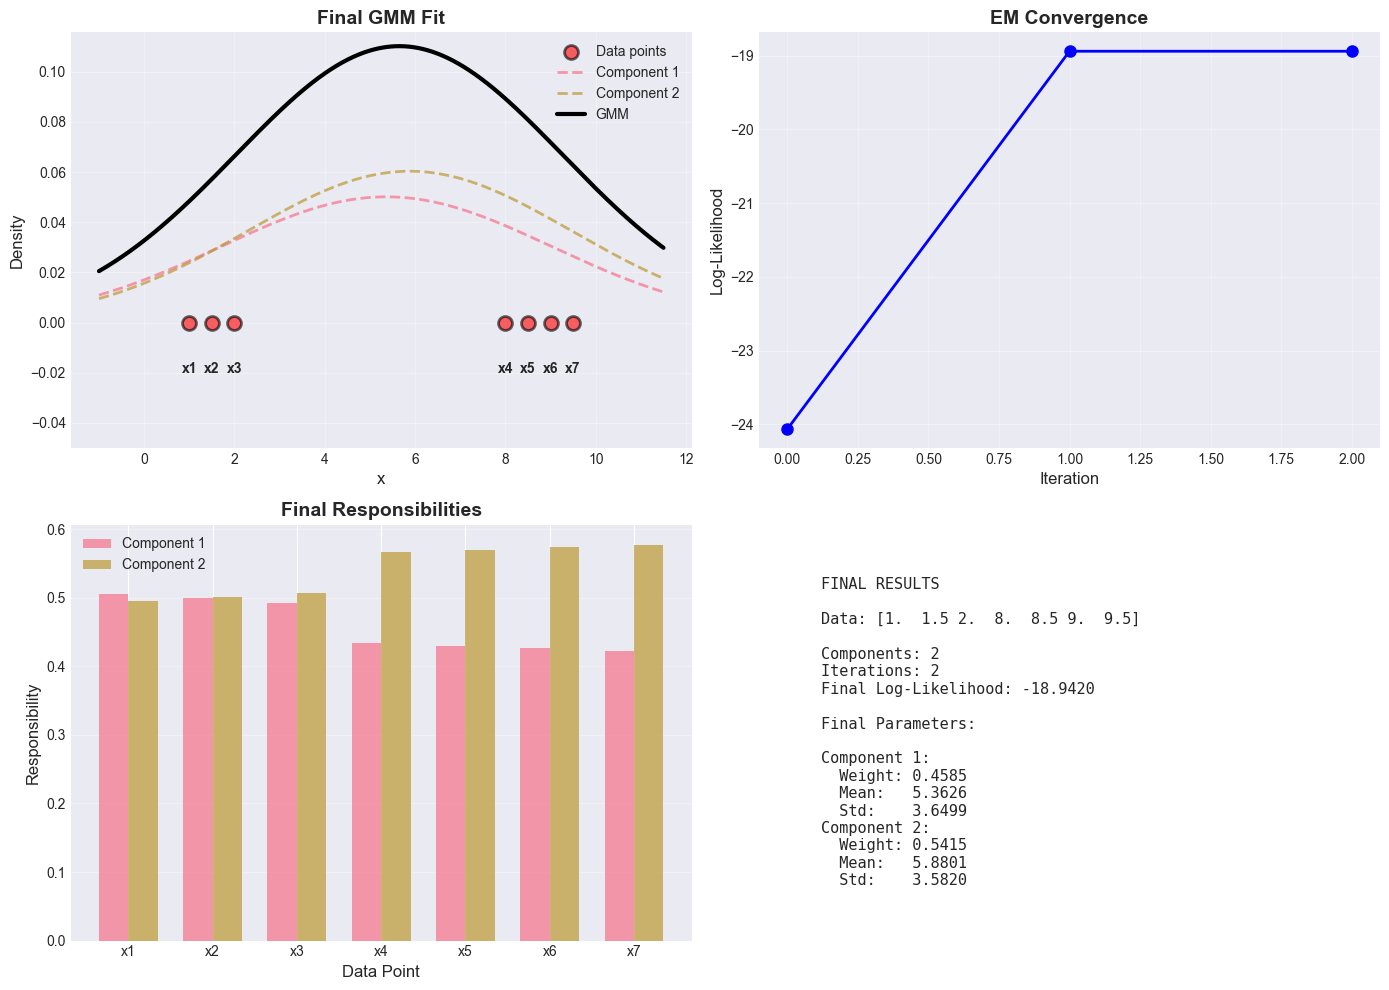


Visualization saved as 'gmm_simple_example.png'


╔════════════════════════════════════════════════════════════════════════════════════════╗
║                                   SESSION COMPLETE!                                    ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

Key Takeaways:
  • Score shows the direction to move parameters
  • Hessian shows curvature (negative = we're at a maximum)
  • Fisher Information tells us precision of parameter estimates
  • EM alternates: E-step (compute responsibilities) → M-step (update params)
  • Responsibilities sum to 1 for each data point

Try modifying the data to see how results change!


In [2]:
"""
GMM Sandbox: Simple Examples for Hand Calculation and Interactive Exploration

This script provides:
1. A simple 5-10 point example you can solve by hand
2. Interactive mode where you can input your own data and parameters

Usage: python gmm_sandbox.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class GMMDerivativesExplorer:
    """Explore Score, Hessian, and Fisher Information for a single Gaussian"""

    def __init__(self, mu=0.0, sigma=1.0):
        self.mu = mu
        self.sigma = sigma

    def log_likelihood(self, x):
        """Compute log-likelihood for a single observation"""
        return norm.logpdf(x, loc=self.mu, scale=self.sigma)

    def score(self, x):
        """Compute the score (gradient) of log-likelihood"""
        score_mu = (x - self.mu) / (self.sigma ** 2)
        score_sigma = ((x - self.mu) ** 2) / (self.sigma ** 3) - 1 / self.sigma
        return score_mu, score_sigma

    def hessian(self, x):
        """Compute the Hessian matrix"""
        hess_mu_mu = -1 / (self.sigma ** 2)
        hess_sigma_sigma = -((x - self.mu) ** 2) / (self.sigma ** 4) + 1 / (self.sigma ** 2)
        hess_mu_sigma = -2 * (x - self.mu) / (self.sigma ** 3)

        H = np.array([[hess_mu_mu, hess_mu_sigma],
                      [hess_mu_sigma, hess_sigma_sigma]])
        return H

    def fisher_information(self):
        """Compute Fisher Information Matrix"""
        I_mu_mu = 1 / (self.sigma ** 2)
        I_sigma_sigma = 2 / (self.sigma ** 2)
        I_mu_sigma = 0

        I = np.array([[I_mu_mu, I_mu_sigma],
                      [I_mu_sigma, I_sigma_sigma]])
        return I

    def analyze_point(self, x):
        """Detailed analysis for one data point"""
        ll = self.log_likelihood(x)
        score_mu, score_sigma = self.score(x)
        H = self.hessian(x)
        I = self.fisher_information()

        print(f"\n{'='*70}")
        print(f"ANALYSIS FOR x = {x:.4f} with mu = {self.mu:.4f}, sigma = {self.sigma:.4f}")
        print(f"{'='*70}")

        print(f"\n1. LOG-LIKELIHOOD:")
        print(f"   L = -log(sigma*sqrt(2*pi)) - (x-mu)^2/(2*sigma^2)")
        print(f"   L = -log({self.sigma:.4f}*sqrt(2*pi)) - ({x:.4f}-{self.mu:.4f})^2/(2*{self.sigma:.4f}^2)")
        print(f"   L = {ll:.6f}")

        print(f"\n2. SCORE (Gradient):")
        print(f"   dL/dmu = (x - mu) / sigma^2")
        print(f"          = ({x:.4f} - {self.mu:.4f}) / {self.sigma:.4f}^2")
        print(f"          = {score_mu:.6f}")
        print(f"   dL/dsigma = (x-mu)^2/sigma^3 - 1/sigma")
        print(f"             = ({x:.4f}-{self.mu:.4f})^2/{self.sigma:.4f}^3 - 1/{self.sigma:.4f}")
        print(f"             = {score_sigma:.6f}")

        print(f"\n3. HESSIAN:")
        print(f"   d2L/dmu^2 = -1/sigma^2 = {H[0,0]:.6f}")
        print(f"   d2L/dsigma^2 = {H[1,1]:.6f}")
        print(f"   d2L/dmu*dsigma = {H[0,1]:.6f}")

        print(f"\n4. FISHER INFORMATION:")
        print(f"   I(mu,mu) = 1/sigma^2 = {I[0,0]:.6f}")
        print(f"   I(sigma,sigma) = 2/sigma^2 = {I[1,1]:.6f}")
        print(f"   Minimum Var(mu_hat) = {1/I[0,0]:.6f}")


class GMMEMAlgorithm:
    """Complete EM Algorithm for Gaussian Mixture Models"""

    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.weights_ = None
        self.means_ = None
        self.stds_ = None
        self.history_ = []

    def _initialize_parameters(self, X):
        """Initialize parameters"""
        n_samples = len(X)
        indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[indices].copy()
        self.stds_ = np.ones(self.n_components) * np.std(X)
        self.weights_ = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        """E-step: Compute responsibilities"""
        n_samples = len(X)
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * norm.pdf(
                X, loc=self.means_[k], scale=self.stds_[k]
            )

        responsibilities /= (responsibilities.sum(axis=1, keepdims=True) + 1e-10)
        return responsibilities

    def _m_step(self, X, responsibilities):
        """M-step: Update parameters"""
        n_samples = len(X)
        N_k = responsibilities.sum(axis=0)
        self.weights_ = N_k / n_samples
        self.means_ = (responsibilities.T @ X) / N_k

        for k in range(self.n_components):
            diff = X - self.means_[k]
            self.stds_[k] = np.sqrt((responsibilities[:, k] * diff ** 2).sum() / N_k[k])

    def _compute_log_likelihood(self, X):
        """Compute log-likelihood"""
        log_likelihood = 0
        for i in range(len(X)):
            prob = 0
            for k in range(self.n_components):
                prob += self.weights_[k] * norm.pdf(X[i], loc=self.means_[k], scale=self.stds_[k])
            log_likelihood += np.log(prob + 1e-10)
        return log_likelihood

    def fit(self, X, verbose=True):
        """Fit GMM using EM algorithm"""
        X = np.array(X).flatten()
        self._initialize_parameters(X)

        self.history_ = [{
            'iteration': 0,
            'means': self.means_.copy(),
            'stds': self.stds_.copy(),
            'weights': self.weights_.copy(),
            'log_likelihood': self._compute_log_likelihood(X),
            'responsibilities': None
        }]

        if verbose:
            print("\n" + "=" * 90)
            print(f"EM ALGORITHM FOR {self.n_components}-COMPONENT GMM")
            print("=" * 90)
            print(f"Data points: {X}")
            print(f"Number of points: {len(X)}")
            print("=" * 90)
            print(f"\n{'Iter':<6} {'LogLik':<12} ", end='')
            for k in range(self.n_components):
                print(f"{'W'+str(k+1):<10} {'Mean'+str(k+1):<10} {'Std'+str(k+1):<10} ", end='')
            print()
            print("-" * 90)

        for iteration in range(1, self.max_iter + 1):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            log_likelihood = self._compute_log_likelihood(X)

            self.history_.append({
                'iteration': iteration,
                'means': self.means_.copy(),
                'stds': self.stds_.copy(),
                'weights': self.weights_.copy(),
                'log_likelihood': log_likelihood,
                'responsibilities': responsibilities.copy()
            })

            if verbose:
                print(f"{iteration:<6} {log_likelihood:<12.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{self.weights_[k]:<10.4f} {self.means_[k]:<10.4f} {self.stds_[k]:<10.4f} ", end='')
                print()

            if iteration > 1:
                ll_change = abs(log_likelihood - self.history_[-2]['log_likelihood'])
                if ll_change < self.tol:
                    if verbose:
                        print(f"\nConverged at iteration {iteration} (change: {ll_change:.8f})")
                    break

        if verbose:
            print("=" * 90)
        return self

    def print_detailed_step(self, X, iteration):
        """Print detailed iteration information with hand-calculation formulas"""
        X = np.array(X).flatten()
        state = self.history_[iteration]

        print("\n" + "=" * 90)
        print(f"DETAILED VIEW: ITERATION {iteration}")
        print("=" * 90)

        print(f"\nData: {X}")

        print(f"\nCurrent Parameters:")
        for k in range(self.n_components):
            print(f"  Component {k+1}: weight={state['weights'][k]:.6f}, "
                  f"mean={state['means'][k]:.6f}, std={state['stds'][k]:.6f}")

        print(f"\nLog-Likelihood: {state['log_likelihood']:.6f}")

        if state['responsibilities'] is not None:
            print(f"\n{'='*90}")
            print("E-STEP: Computing Responsibilities")
            print(f"{'='*90}")
            print("\nFor each point x_i, compute gamma_ik = P(component k | x_i)")
            print("Formula: gamma_ik = [weight_k * N(x_i | mu_k, sigma_k)] / Sum_j[weight_j * N(x_i | mu_j, sigma_j)]")
            print("\nWhere N(x | mu, sigma) = (1/sqrt(2*pi*sigma^2)) * exp(-(x-mu)^2/(2*sigma^2))")

            print(f"\n{'Point':<8} {'Value':<10} ", end='')
            for k in range(self.n_components):
                print(f"{'gamma_'+str(k+1):<12} ", end='')
            print()
            print("-" * 80)

            for i in range(len(X)):
                print(f"x_{i+1:<6} {X[i]:<10.4f} ", end='')
                for k in range(self.n_components):
                    print(f"{state['responsibilities'][i, k]:<12.6f} ", end='')
                print()

            print(f"\n{'='*90}")
            print("M-STEP: Updating Parameters")
            print(f"{'='*90}")

            N_k = state['responsibilities'].sum(axis=0)
            print("\nEffective number of points per component (N_k):")
            for k in range(self.n_components):
                print(f"  N_{k+1} = Sum_i gamma_{k+1,i} = {N_k[k]:.6f}")

            print("\nUpdate formulas:")
            print("  weight_k = N_k / N_total")
            print("  mean_k = Sum_i(gamma_ik * x_i) / N_k")
            print("  std_k = sqrt(Sum_i(gamma_ik * (x_i - mean_k)^2) / N_k)")

            if iteration < len(self.history_) - 1:
                next_state = self.history_[iteration + 1]
                print(f"\nNew parameters (will be used in iteration {iteration + 1}):")
                for k in range(self.n_components):
                    print(f"  Component {k+1}: weight={next_state['weights'][k]:.6f}, "
                          f"mean={next_state['means'][k]:.6f}, std={next_state['stds'][k]:.6f}")

    def visualize_simple(self, X):
        """Simple visualization for small datasets"""
        X = np.array(X).flatten()

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 1: Data points and final GMM
        state = self.history_[-1]
        x_range = np.linspace(X.min() - 2, X.max() + 2, 500)

        axes[0, 0].scatter(X, np.zeros_like(X), s=100, c='red', alpha=0.6,
                          edgecolors='black', linewidths=2, zorder=3, label='Data points')

        gmm_pdf = np.zeros_like(x_range)
        for k in range(self.n_components):
            component_pdf = state['weights'][k] * norm.pdf(
                x_range, loc=state['means'][k], scale=state['stds'][k]
            )
            axes[0, 0].plot(x_range, component_pdf, '--', linewidth=2,
                           label=f'Component {k+1}', alpha=0.7)
            gmm_pdf += component_pdf

        axes[0, 0].plot(x_range, gmm_pdf, 'k-', linewidth=3, label='GMM')

        for i, x in enumerate(X):
            axes[0, 0].text(x, -0.02, f'x{i+1}', ha='center', fontsize=10, fontweight='bold')

        axes[0, 0].set_xlabel('x', fontsize=12)
        axes[0, 0].set_ylabel('Density', fontsize=12)
        axes[0, 0].set_title('Final GMM Fit', fontsize=14, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_ylim(bottom=-0.05)

        # Plot 2: Log-likelihood convergence
        iterations = [s['iteration'] for s in self.history_]
        log_likelihoods = [s['log_likelihood'] for s in self.history_]

        axes[0, 1].plot(iterations, log_likelihoods, 'bo-', linewidth=2, markersize=8)
        axes[0, 1].set_xlabel('Iteration', fontsize=12)
        axes[0, 1].set_ylabel('Log-Likelihood', fontsize=12)
        axes[0, 1].set_title('EM Convergence', fontsize=14, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3)

        # Plot 3: Responsibility evolution
        if self.history_[-1]['responsibilities'] is not None:
            resp = self.history_[-1]['responsibilities']

            x_pos = np.arange(len(X))
            width = 0.35 if self.n_components == 2 else 0.25

            for k in range(self.n_components):
                offset = (k - (self.n_components - 1) / 2) * width
                axes[1, 0].bar(x_pos + offset, resp[:, k], width,
                              label=f'Component {k+1}', alpha=0.7)

            axes[1, 0].set_xlabel('Data Point', fontsize=12)
            axes[1, 0].set_ylabel('Responsibility', fontsize=12)
            axes[1, 0].set_title('Final Responsibilities', fontsize=14, fontweight='bold')
            axes[1, 0].set_xticks(x_pos)
            axes[1, 0].set_xticklabels([f'x{i+1}' for i in range(len(X))])
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3, axis='y')

        # Plot 4: Summary text
        axes[1, 1].axis('off')
        summary = f"""FINAL RESULTS

Data: {X}

Components: {self.n_components}
Iterations: {len(self.history_) - 1}
Final Log-Likelihood: {self.history_[-1]['log_likelihood']:.4f}

Final Parameters:
"""
        for k in range(self.n_components):
            state = self.history_[-1]
            summary += f"\nComponent {k+1}:"
            summary += f"\n  Weight: {state['weights'][k]:.4f}"
            summary += f"\n  Mean:   {state['means'][k]:.4f}"
            summary += f"\n  Std:    {state['stds'][k]:.4f}"

        axes[1, 1].text(0.1, 0.5, summary, fontsize=11, family='monospace',
                       verticalalignment='center')

        plt.tight_layout()
        plt.savefig('gmm_simple_example.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nVisualization saved as 'gmm_simple_example.png'")


def example_1_simple_case():
    """Example 1: Simple 7-point example for hand calculation"""
    print("\n" + "╔" + "═" * 88 + "╗")
    print("║" + " " * 20 + "EXAMPLE 1: SIMPLE 7-POINT CASE (EASY TO VERIFY BY HAND)" + " " * 12 + "║")
    print("╚" + "═" * 88 + "╝")

    # Simple data: clearly two groups
    X = np.array([1.0, 1.5, 2.0, 8.0, 8.5, 9.0, 9.5])

    print(f"\nData points: {X}")
    print("These points clearly form TWO groups: around 1.5 and around 8.75")

    # First, demonstrate derivatives on a single point
    print("\n" + "─" * 90)
    print("PART A: Understanding Derivatives (using one point)")
    print("─" * 90)

    explorer = GMMDerivativesExplorer(mu=2.0, sigma=1.0)
    explorer.analyze_point(x=1.5)

    # Now run EM
    print("\n\n" + "─" * 90)
    print("PART B: EM Algorithm on All Points")
    print("─" * 90)

    np.random.seed(42)  # For reproducible results
    gmm = GMMEMAlgorithm(n_components=2, max_iter=20)
    gmm.fit(X, verbose=True)

    # Show detailed steps
    print("\n" + "┌" + "─" * 88 + "┐")
    print("│" + " " * 30 + "DETAILED STEP-BY-STEP BREAKDOWN" + " " * 27 + "│")
    print("└" + "─" * 88 + "┘")

    gmm.print_detailed_step(X, iteration=0)
    gmm.print_detailed_step(X, iteration=1)
    gmm.print_detailed_step(X, iteration=2)
    gmm.print_detailed_step(X, iteration=-1)

    # Visualize
    gmm.visualize_simple(X)


def example_2_interactive():
    """Example 2: Interactive mode - user inputs their own data"""
    print("\n" + "╔" + "═" * 88 + "╗")
    print("║" + " " * 25 + "EXAMPLE 2: INTERACTIVE MODE (YOUR DATA)" + " " * 24 + "║")
    print("╚" + "═" * 88 + "╝")

    print("\nYou can now input your own data and parameters!")
    print("This allows you to experiment and see how changes affect the results.")

    # Get data from user
    print("\n" + "─" * 90)
    print("Step 1: Enter your data points")
    print("─" * 90)
    print("Examples:")
    print("  - For 2 clusters: 1 2 3 10 11 12")
    print("  - For 3 clusters: 0 1 5 6 10 11")
    print("  - Single cluster: 5 5.5 6 6.5 7")

    user_input = input("\nEnter data points (space-separated numbers): ").strip()

    if user_input:
        try:
            X = np.array([float(x) for x in user_input.split()])
            print(f"\nYour data: {X}")
            print(f"Number of points: {len(X)}")
            print(f"Range: [{X.min():.2f}, {X.max():.2f}]")
            print(f"Mean: {X.mean():.2f}, Std: {X.std():.2f}")
        except:
            print("Invalid input! Using default data: [1, 2, 3, 8, 9, 10]")
            X = np.array([1, 2, 3, 8, 9, 10])
    else:
        print("No input provided. Using default data: [1, 2, 3, 8, 9, 10]")
        X = np.array([1, 2, 3, 8, 9, 10])

    # Get number of components
    print("\n" + "─" * 90)
    print("Step 2: Choose number of components")
    print("─" * 90)

    n_comp_input = input("Enter number of components (2 or 3, default=2): ").strip()

    try:
        n_components = int(n_comp_input)
        if n_components not in [2, 3]:
            print("Invalid! Using 2 components.")
            n_components = 2
    except:
        n_components = 2

    print(f"\nFitting {n_components}-component GMM...")

    # Optional: analyze derivatives for first point
    print("\n" + "─" * 90)
    print("Step 3: Derivative Analysis (Optional)")
    print("─" * 90)

    analyze = input("Analyze derivatives for first data point? (y/n, default=n): ").strip().lower()

    if analyze == 'y':
        mu_input = input(f"Enter mu (default={X.mean():.2f}): ").strip()
        sigma_input = input(f"Enter sigma (default={X.std():.2f}): ").strip()

        mu = float(mu_input) if mu_input else X.mean()
        sigma = float(sigma_input) if sigma_input else X.std()

        explorer = GMMDerivativesExplorer(mu=mu, sigma=sigma)
        explorer.analyze_point(x=X[0])

    # Run EM
    print("\n" + "─" * 90)
    print("Step 4: Running EM Algorithm")
    print("─" * 90)

    np.random.seed(42)
    gmm = GMMEMAlgorithm(n_components=n_components, max_iter=30)
    gmm.fit(X, verbose=True)

    # Show detailed steps
    show_details = input("\nShow detailed step-by-step breakdown? (y/n, default=y): ").strip().lower()

    if show_details != 'n':
        gmm.print_detailed_step(X, iteration=0)
        gmm.print_detailed_step(X, iteration=1)
        gmm.print_detailed_step(X, iteration=-1)

    # Visualize
    gmm.visualize_simple(X)

    print("\n" + "═" * 90)
    print("INTERACTIVE SESSION COMPLETE!")
    print("═" * 90)


def main():
    """Main function"""
    print("\n" + "╔" + "═" * 88 + "╗")
    print("║" + " " * 15 + "GMM SANDBOX: LEARN BY DOING SIMPLE HAND CALCULATIONS" + " " * 16 + "║")
    print("╚" + "═" * 88 + "╝")

    print("\nThis program demonstrates GMM concepts with SMALL datasets")
    print("so you can verify calculations by hand and truly understand the algorithms.")

    print("\n\nChoose an option:")
    print("  1. Example 1: Simple 7-point case (recommended for learning)")
    print("  2. Example 2: Interactive mode (enter your own data)")
    print("  3. Run both examples")

    choice = input("\nEnter choice (1/2/3, default=1): ").strip()

    if choice == '2':
        example_2_interactive()
    elif choice == '3':
        example_1_simple_case()
        input("\n\nPress Enter to continue to interactive mode...")
        example_2_interactive()
    else:
        example_1_simple_case()

    print("\n\n" + "╔" + "═" * 88 + "╗")
    print("║" + " " * 35 + "SESSION COMPLETE!" + " " * 36 + "║")
    print("╚" + "═" * 88 + "╝")
    print("\nKey Takeaways:")
    print("  • Score shows the direction to move parameters")
    print("  • Hessian shows curvature (negative = we're at a maximum)")
    print("  • Fisher Information tells us precision of parameter estimates")
    print("  • EM alternates: E-step (compute responsibilities) → M-step (update params)")
    print("  • Responsibilities sum to 1 for each data point")
    print("\nTry modifying the data to see how results change!")


if __name__ == "__main__":
    main()